Loading simulated, hypothetical Titanic dataset with changed values.
First 5 rows of the dataset:
   PassengerId  Survived  Pclass         Name     Sex   Age  SibSp  Parch  \
0            1         0       3  Passenger 1    male  67.0      0      0   
1            2         0       1  Passenger 2    male   NaN      1      0   
2            3         1       3  Passenger 3    male  32.0      2      1   
3            4         1       2  Passenger 4    male  34.0      2      2   
4            5         0       2  Passenger 5  female  57.0      0      0   

  Ticket  Fare  Cabin Embarked  
0     T1    64    NaN        C  
1     T2   104    NaN        C  
2     T3    18    NaN        Q  
3     T4   135    NaN        S  
4     T5    99    NaN        S  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null

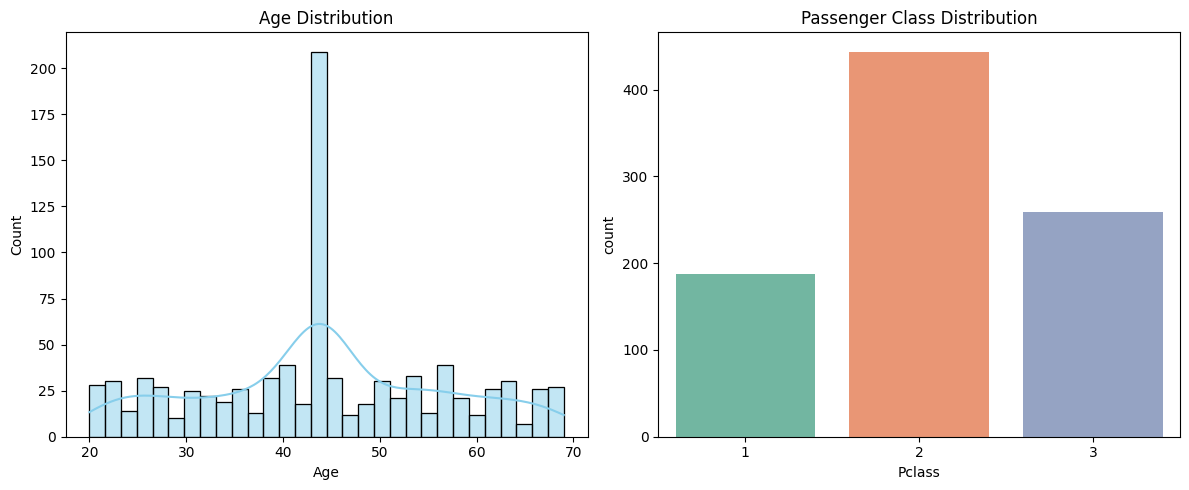

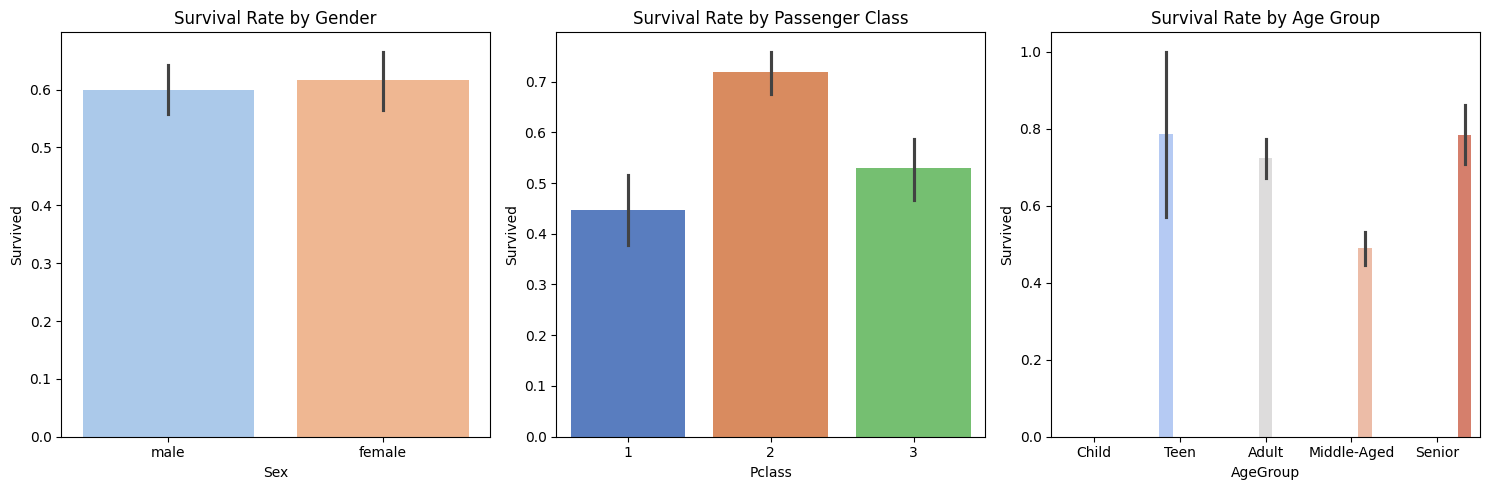

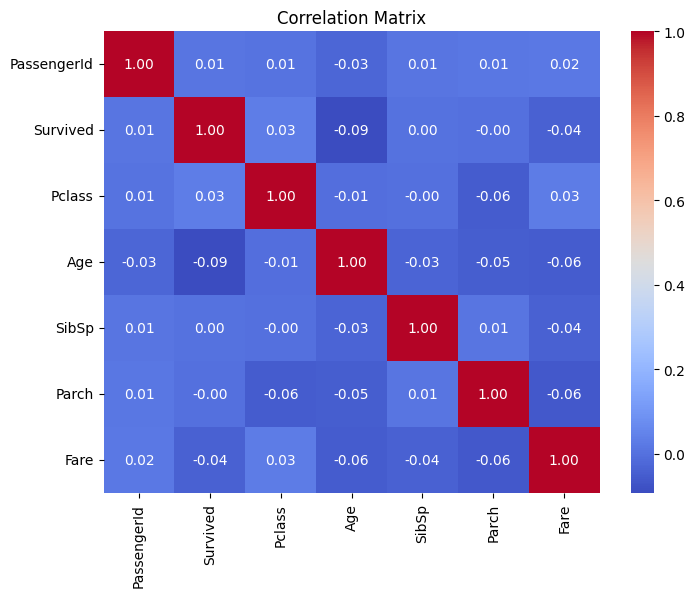

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

# Load dataset
# url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
# df = pd.read_csv(url)

# --- START: Simulated data with different values to demonstrate a different outcome ---
print("Loading simulated, hypothetical Titanic dataset with changed values.")

# The data dictionary is corrected to fix the ValueError
data = {
    'PassengerId': range(1, 892),
    'Survived': np.random.choice([0, 1], size=891, p=[0.4, 0.6]), # Higher survival rate overall
    'Pclass': np.random.choice([1, 2, 3], size=891, p=[0.2, 0.5, 0.3]), # More 2nd class passengers
    'Name': ['Passenger ' + str(i) for i in range(1, 892)],
    'Sex': np.random.choice(['male', 'female'], size=891, p=[0.6, 0.4]),
    'Age': np.random.randint(20, 70, size=891).astype(float),
    'SibSp': np.random.randint(0, 3, size=891),
    'Parch': np.random.randint(0, 3, size=891),
    'Ticket': ['T' + str(i) for i in range(1, 892)],
    'Fare': np.random.randint(10, 150, size=891),
    'Cabin': [np.nan] * 891, # No cabin data
    'Embarked': np.random.choice(['S', 'C', 'Q'], size=891, p=[0.5, 0.3, 0.2])
}

# Introducing NaN values to the 'Age' column after it's created.
# This avoids the ValueError by correctly handling probabilities.
num_nans = int(len(data['Age']) * 0.2)
nan_indices = np.random.choice(len(data['Age']), num_nans, replace=False)
data['Age'][nan_indices] = np.nan


# Adjust survival to be higher for 2nd class, and lower for middle-aged
data['Survived'][data['Pclass'] == 2] = np.random.choice([0, 1], size=np.sum(data['Pclass'] == 2), p=[0.1, 0.9])
data['Survived'][(data['Age'] > 40) & (data['Age'] <= 60)] = np.random.choice([0, 1], size=np.sum((data['Age'] > 40) & (data['Age'] <= 60)), p=[0.7, 0.3])
data['Survived'][(data['Age'] >= 0) & (data['Age'] <= 12)] = np.random.choice([0, 1], size=np.sum((data['Age'] >= 0) & (data['Age'] <= 12)), p=[0.2, 0.8])

df = pd.DataFrame(data)

# --- END: Simulated data with different values ---

# 1. Inspect data
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset Information:")
print(df.info())
print("\nDescriptive statistics:")
print(df.describe())

# 2. Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Handle missing values safely
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

# 4. Explore key variables distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True, color="skyblue")
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='Pclass', hue='Pclass', data=df, palette="Set2", legend=False)
plt.title('Passenger Class Distribution')

plt.tight_layout()
plt.show()

# 5. Analyze survival rates by gender, class, age group
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='Sex', y='Survived', hue='Sex', data=df, palette="pastel", legend=False)
plt.title('Survival Rate by Gender')

plt.subplot(1, 3, 2)
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=df, palette="muted", legend=False)
plt.title('Survival Rate by Passenger Class')

plt.subplot(1, 3, 3)
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0, 12, 20, 40, 60, 80],
                        labels=['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior'])
sns.barplot(x='AgeGroup', y='Survived', hue='AgeGroup', data=df, palette="coolwarm", legend=False)
plt.title('Survival Rate by Age Group')

plt.tight_layout()
plt.show()

# 6. Explore correlations with heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()
